In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
np.random.seed(42)
X = 6 * np.random.rand(10000, 1) - 3
# # y = 0.5 * x^2 + x + 2 + noise
y = 0.5 * X**2 + X + 2 + np.random.randn(10000, 1)
df = pd.DataFrame({'X':list(X.reshape(-1,)), 'Y':list(y.reshape(-1))})
df

,X,Y
0,-0.752759,0.042702
1,2.704286,7.235681
2,1.391964,4.749564
3,0.591951,1.593281
4,-2.063888,3.178563
...,...,...
9995,2.145936,6.420332
9996,2.385053,8.021687
9997,2.680247,9.266629
9998,-0.615072,0.876755


<Axes: >

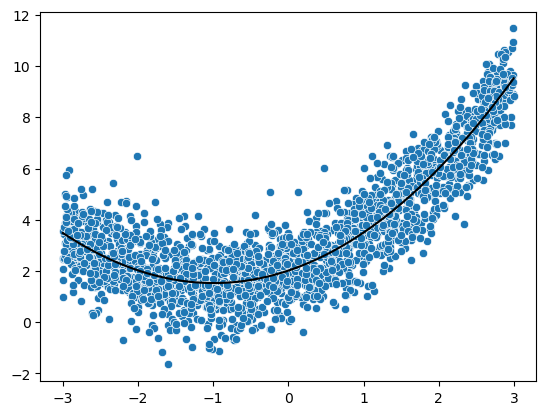

In [112]:
# sns.scatterplot(df,x='X',y='Y')
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
X_train,X_test ,y_train ,y_test = train_test_split(df.iloc[:,[0]],df.iloc[:,[1]],test_size=0.2,random_state=90)


lr = LinearRegression()



pipe = Pipeline(steps=[('Poly',PolynomialFeatures(degree=3)),
                       ('stand',StandardScaler()),
                       ('Model',lr)])
pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)
sns.scatterplot(x=X_test.values.flatten(), y=y_test.values.flatten())
sns.lineplot(x=X_test.values.flatten(), y=y_pred.flatten(),color='black')
